In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import base64
import random

In [6]:
final_df = pd.read_csv(r"C:\Bizmetric\vedanta\ebitda_walk.csv")

In [7]:
final_df

,Period,EBITDA_From_Quarter,Sales,LME,Strategic Hedging,Premium,Realization,Total Cost,Alumina,Power,Other Hot Metal,Conversion & Other,EBITDA_Margin,EBITDA_Impact,EBITDA_To_Quarter
0,EW_Q1FY24_Q1FY24,221,0,0,0,0,0,0,0,0,0,0,0,0,221
1,EW_Q1FY24_Q2FY24,221,9,-59,-2,12,-49,55,43,10,14,-11,7,16,238
2,EW_Q1FY24_Q3FY24,221,13,-38,-5,-1,-44,149,37,25,49,38,106,124,346
3,EW_Q1FY24_Q4FY24,221,15,-33,-5,-8,-46,163,48,14,63,38,117,140,361
4,EW_Q2FY24_Q1FY24,238,-10,61,2,-12,51,-58,-45,-10,-14,11,-7,-16,221
5,EW_Q2FY24_Q2FY24,238,0,0,0,0,0,0,0,0,0,0,0,0,238
6,EW_Q2FY24_Q3FY24,238,3,21,-3,-13,5,98,-6,17,37,51,103,108,346
7,EW_Q2FY24_Q4FY24,238,6,27,-3,-21,3,112,5,5,51,51,115,123,361
8,EW_Q3FY24_Q1FY24,346,-18,41,5,1,46,-158,-39,-27,-51,-40,-112,-124,221
9,EW_Q3FY24_Q2FY24,346,-5,-22,3,13,-5,-99,6,-17,-37,-51,-105,-108,238


In [21]:


# 2. 🛠 Helper to convert fig to base64 (for mimic)
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

# 3. 📈 Waterfall Chart Plotting Function
def plot_ebitda_walk(df_row):
    labels = [
        "EBITDA_From_Quarter", "Sales", "LME", "Strategic Hedging", "Premium", 
         "Alumina", "Power", "Other Hot Metal", "Conversion & Other", "EBITDA_To_Quarter"
    ]
    values = [df_row[label] for label in labels]

    fig, ax = plt.subplots(figsize=(12, 5))  # Slightly taller figure to prevent touching

    # Waterfall base calculation
    cum_values = [values[0]]
    for v in values[1:-1]:
        cum_values.append(cum_values[-1] + v)
    cum_values.append(values[-1])

    colors = ['navy'] + ['limegreen' if v >= 0 else 'red' for v in values[1:-1]] + ['navy']

    # Plot bars
    prev = 0
    bar_width = 0.6  # Slightly thinner bars
    for i in range(len(values)):
        if i == 0 or i == len(values) - 1:
            ax.bar(i, values[i], color=colors[i], width=bar_width)
            height = values[i]
            y = 0
        else:
            height = values[i]
            y = prev
            ax.bar(i, height, bottom=y, color=colors[i], width=bar_width)
        prev = y + height

    # X-ticks
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")

    # Title and grid
    ax.set_title("EBITDA Walk (Mn$)")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Compute y-limits manually to leave space
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.2)  # 20% extra headroom

    # Add value labels neatly
    for i, (labels, value) in enumerate(zip(labels, values)):
        if i == 0 or i == len(labels) - 1:
            ypos = value + (0.05 * ymax) if value >= 0 else value - (0.05 * ymax)
            ax.text(i, ypos, f"{int(value)}", ha='center', va='bottom', fontsize=9, fontweight='bold')
        else:
            ypos = cum_values[i-1] + (value/2)
            ax.text(i, ypos, f"{int(value)}", ha='center', va='center', fontsize=8)

    # Add legend manually, move it lower
    increase_patch = mpatches.Patch(color='limegreen', label='Increase')
    decrease_patch = mpatches.Patch(color='red', label='Decrease')
    total_patch = mpatches.Patch(color='navy', label='Total')
    ax.legend(handles=[increase_patch, decrease_patch, total_patch], loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)

    plt.tight_layout()
    return fig





In [22]:
# 5. 🛠 Mimic function to select quarters manually and plot
def generate_ebitda_walk_from_quarters(final_df, source_quarter, target_quarter):
    # row_name = f"EW_{source_quarter}_{target_quarter}"
    
    # expected_period = f"EW_{source_quarter}_{target_quarter}"

    # # Search in 'Period' column
    # row_name = final_df[final_df['Period'] == expected_period]

    # if row_name.empty:
    #     print(f"❌ Row '{row_name}' not found in data.")
    #     return

    # selected_row = final_df.loc[row_name]
    # fig = plot_ebitda_walk(selected_row)
    expected_period = f"EW_{source_quarter}_{target_quarter}"

    # Search in 'Period' column
    row_match = final_df[final_df['Period'] == expected_period]

    if row_match.empty:
        print(f"❌ Row with Period='{expected_period}' not found.")
        return

    selected_row = row_match.iloc[0]
    fig = plot_ebitda_walk(selected_row)


    # Display in Notebook
    plt.show()


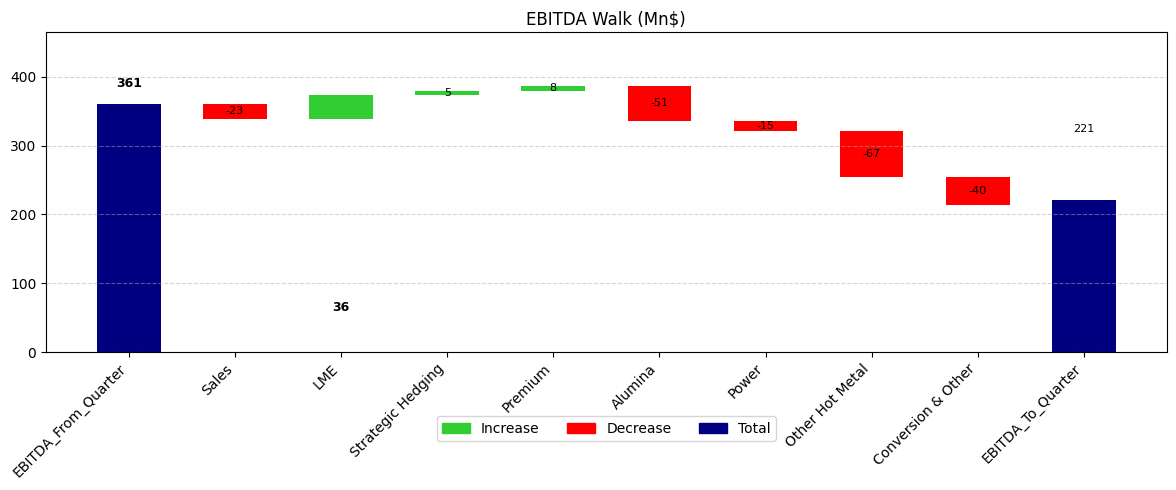

In [23]:

# 6. 🚀 Test Example
source_quarter = "Q4FY24"
target_quarter = "Q1FY24"


generate_ebitda_walk_from_quarters(final_df, source_quarter, target_quarter)
